# Human Activity Recognition using Machine Learning

## Objective
The objective of this project is to build a Human Activity Recognition (HAR) system using the official WISDM Activity Recognition dataset. Three machine learning algorithms (Decision Tree, K-Nearest Neighbors, and Random Forest) are trained and evaluated to classify six human activities based on smartphone sensor-derived features.

# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import os

# 2. Load the Dataset

The transformed WISDM dataset is loaded into a Pandas DataFrame for preprocessing and machine learning.

In [2]:
import re

# Path to your dataset
file_path ="WISDM_ar_v1.1_transformed.arff"

# Read file
with open(file_path, "r") as f:
    lines = f.readlines()

# Find where the data starts
data_start = 0
attributes = []

for i, line in enumerate(lines):
    line = line.strip()

    if line.lower().startswith("@attribute"):
        parts = re.split(r"\s+", line, maxsplit=2)
        attributes.append(parts[1])

    if line.lower() == "@data":
        data_start = i + 1
        break

# Read the data rows
rows = []

for line in lines[data_start:]:
    line = line.strip()

    if line == "" or line.startswith("%"):
        continue

    rows.append(line.split(","))

# Create dataframe
df = pd.DataFrame(rows, columns=attributes)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [3]:
df.head()

,"""UNIQUE_ID""","""user""","""X0""","""X1""","""X2""","""X3""","""X4""","""X5""","""X6""","""X7""",...,"""YPEAK""","""ZPEAK""","""XABSOLDEV""","""YABSOLDEV""","""ZABSOLDEV""","""XSTANDDEV""","""YSTANDDEV""","""ZSTANDDEV""","""RESULTANT""",class{
0,1,33,0.04,0.09,0.14,0.12,0.11,0.1,0.08,0.13,...,293.94,1550,3.29,7.21,4,4.05,8.17,4.05,11.96,Jogging
1,2,33,0.12,0.12,0.06,0.07,0.11,0.1,0.11,0.09,...,269.44,1233.33,4.23,6.88,4.05,5.43,8.19,5.43,12.05,Jogging
2,3,33,0.14,0.09,0.11,0.09,0.09,0.11,0.12,0.08,...,248.65,1780,4.18,6.89,4.07,5.55,8.19,5.55,11.99,Jogging
3,4,33,0.06,0.1,0.09,0.09,0.11,0.07,0.12,0.1,...,709.09,1380,2.26,4.13,2.49,2.87,4.95,2.87,10.69,Walking
4,5,33,0.12,0.11,0.1,0.08,0.1,0.14,0.1,0.11,...,3300,1775,2.29,3.94,2.41,3.08,4.64,3.08,10.8,Walking


In [4]:
print("Shape: ", df.shape)

Shape:  (5418, 46)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5418 entries, 0 to 5417
Data columns (total 46 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   "UNIQUE_ID"  5418 non-null   object
 1   "user"       5418 non-null   object
 2   "X0"         5418 non-null   object
 3   "X1"         5418 non-null   object
 4   "X2"         5418 non-null   object
 5   "X3"         5418 non-null   object
 6   "X4"         5418 non-null   object
 7   "X5"         5418 non-null   object
 8   "X6"         5418 non-null   object
 9   "X7"         5418 non-null   object
 10  "X8"         5418 non-null   object
 11  "X9"         5418 non-null   object
 12  "Y0"         5418 non-null   object
 13  "Y1"         5418 non-null   object
 14  "Y2"         5418 non-null   object
 15  "Y3"         5418 non-null   object
 16  "Y4"         5418 non-null   object
 17  "Y5"         5418 non-null   object
 18  "Y6"         5418 non-null   object
 19  "Y7"         5418 non-null 

In [6]:
df.isnull().sum()

"UNIQUE_ID"    0
"user"         0
"X0"           0
"X1"           0
"X2"           0
"X3"           0
"X4"           0
"X5"           0
"X6"           0
"X7"           0
"X8"           0
"X9"           0
"Y0"           0
"Y1"           0
"Y2"           0
"Y3"           0
"Y4"           0
"Y5"           0
"Y6"           0
"Y7"           0
"Y8"           0
"Y9"           0
"Z0"           0
"Z1"           0
"Z2"           0
"Z3"           0
"Z4"           0
"Z5"           0
"Z6"           0
"Z7"           0
"Z8"           0
"Z9"           0
"XAVG"         0
"YAVG"         0
"ZAVG"         0
"XPEAK"        0
"YPEAK"        0
"ZPEAK"        0
"XABSOLDEV"    0
"YABSOLDEV"    0
"ZABSOLDEV"    0
"XSTANDDEV"    0
"YSTANDDEV"    0
"ZSTANDDEV"    0
"RESULTANT"    0
class{         0
dtype: int64

In [7]:
print(df.columns.tolist())

['"UNIQUE_ID"', '"user"', '"X0"', '"X1"', '"X2"', '"X3"', '"X4"', '"X5"', '"X6"', '"X7"', '"X8"', '"X9"', '"Y0"', '"Y1"', '"Y2"', '"Y3"', '"Y4"', '"Y5"', '"Y6"', '"Y7"', '"Y8"', '"Y9"', '"Z0"', '"Z1"', '"Z2"', '"Z3"', '"Z4"', '"Z5"', '"Z6"', '"Z7"', '"Z8"', '"Z9"', '"XAVG"', '"YAVG"', '"ZAVG"', '"XPEAK"', '"YPEAK"', '"ZPEAK"', '"XABSOLDEV"', '"YABSOLDEV"', '"ZABSOLDEV"', '"XSTANDDEV"', '"YSTANDDEV"', '"ZSTANDDEV"', '"RESULTANT"', 'class{']


In [8]:
# Remove quotation marks from column names
df.columns = df.columns.str.replace('"', '', regex=False)

# Rename the last column
df.rename(columns={"class{": "class"}, inplace=True)

In [9]:
print(df["class"].value_counts())

class
Walking       2081
Jogging       1625
Upstairs       632
Downstairs     528
Sitting        306
Standing       246
Name: count, dtype: int64


In [10]:
(df == "?").sum().sum()

np.int64(615)

# 3. Data Preprocessing

The preprocessing stage involves:

- Replacing missing values
- Converting feature columns to numeric
- Removing unnecessary columns
- Preparing the dataset for machine learning

In [11]:
df.replace("?", np.nan, inplace = True)
df.isnull().sum().sum()

np.int64(615)

In [12]:
feature_cols = df.columns[:-1]

df[feature_cols] = df[feature_cols].apply(
    pd.to_numeric, 
    errors="coerce"
    )

In [13]:
df.isnull().sum().sort_values(ascending=False)

XPEAK        381
YPEAK        131
ZPEAK        103
X0             0
UNIQUE_ID      0
user           0
X4             0
X5             0
X6             0
X7             0
X8             0
X1             0
X2             0
X3             0
Y1             0
Y0             0
X9             0
Y2             0
Y6             0
Y3             0
Y4             0
Y5             0
Z0             0
Z1             0
Z2             0
Z3             0
Z4             0
Y7             0
Y8             0
Y9             0
Z7             0
Z6             0
Z5             0
Z8             0
YAVG           0
XAVG           0
Z9             0
ZAVG           0
XABSOLDEV      0
YABSOLDEV      0
ZABSOLDEV      0
XSTANDDEV      0
YSTANDDEV      0
ZSTANDDEV      0
RESULTANT      0
class          0
dtype: int64

In [14]:
df.dropna(inplace=True)

print(df.shape)

(4944, 46)


### Removing Unnecessary Features

The columns **UNIQUE_ID** and **user** are removed because they do not contribute to activity recognition and may introduce bias into the model.

In [15]:
df.drop(columns=["UNIQUE_ID", "user"], inplace=True)

In [16]:
df.shape

(4944, 44)

In [17]:
df.isnull().sum().sort_values(ascending=False)

X0           0
X1           0
X2           0
X3           0
X4           0
X5           0
X6           0
X7           0
X8           0
X9           0
Y0           0
Y1           0
Y2           0
Y3           0
Y4           0
Y5           0
Y6           0
Y7           0
Y8           0
Y9           0
Z0           0
Z1           0
Z2           0
Z3           0
Z4           0
Z5           0
Z6           0
Z7           0
Z8           0
Z9           0
XAVG         0
YAVG         0
ZAVG         0
XPEAK        0
YPEAK        0
ZPEAK        0
XABSOLDEV    0
YABSOLDEV    0
ZABSOLDEV    0
XSTANDDEV    0
YSTANDDEV    0
ZSTANDDEV    0
RESULTANT    0
class        0
dtype: int64

In [18]:
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1] - 1)

Number of samples: 4944
Number of features: 43


# 4. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset by visualizing activity distribution and examining relationships among features.

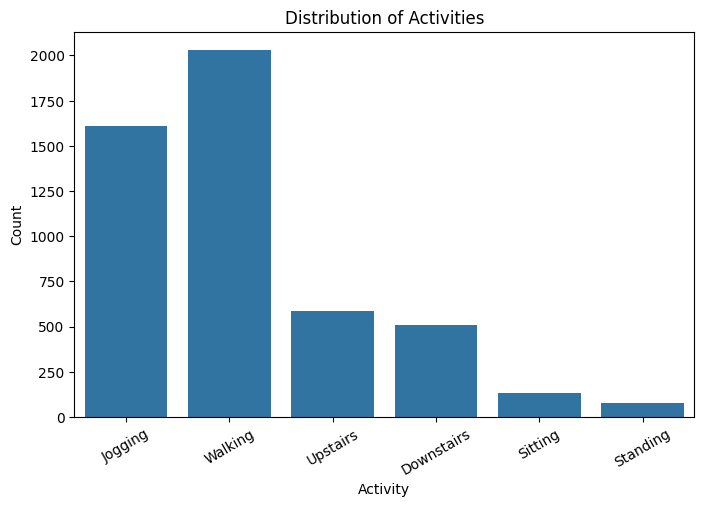

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(x="class", data=df)

plt.title("Distribution of Activities")
plt.xlabel("Activity")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.savefig("images/activity_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [20]:
print(df["class"].value_counts())

class
Walking       2029
Jogging       1612
Upstairs       587
Downstairs     507
Sitting        134
Standing        75
Name: count, dtype: int64


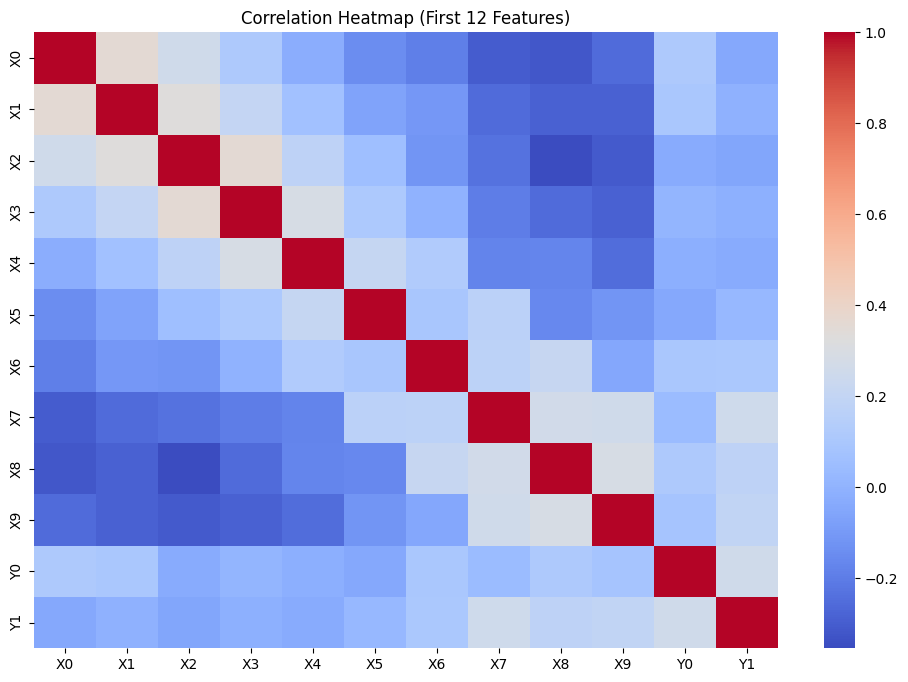

In [21]:
plt.figure(figsize=(12,8))

corr = df.iloc[:, :12].corr()

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Heatmap (First 12 Features)")

plt.show()

In [22]:
df.describe()

,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,XPEAK,YPEAK,ZPEAK,XABSOLDEV,YABSOLDEV,ZABSOLDEV,XSTANDDEV,YSTANDDEV,ZSTANDDEV,RESULTANT
count,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,...,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000,4944.000000
mean,0.093762,0.099780,0.099308,0.097474,0.098999,0.100356,0.099349,0.100738,0.101420,0.090477,...,1861.414697,1090.591557,2110.732002,5.056084,4.351537,3.001648,6.286729,5.426327,6.286729,11.756665
std,0.059022,0.045949,0.042140,0.037467,0.039150,0.039363,0.037254,0.041442,0.053047,0.073427,...,1044.697332,786.955666,998.656368,2.724304,2.126965,1.455800,3.153466,2.377317,3.153466,2.368646
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,125.000000,100.000000,116.670000,0.070000,0.010000,0.020000,0.080000,0.020000,0.080000,0.670000
25%,0.060000,0.080000,0.080000,0.080000,0.080000,0.080000,0.080000,0.080000,0.080000,0.050000,...,1075.000000,527.780000,1432.497500,2.797500,2.920000,2.060000,3.707500,3.850000,3.707500,10.570000
50%,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.100000,0.090000,...,1700.000000,835.710000,2016.670000,4.440000,3.750000,2.760000,5.590000,4.790000,5.590000,11.460000
75%,0.120000,0.120000,0.120000,0.120000,0.120000,0.120000,0.120000,0.120000,0.120000,0.120000,...,2525.000000,1400.000000,2733.330000,7.370000,6.252500,3.820000,9.160000,7.600000,9.160000,12.920000
max,0.700000,0.620000,0.760000,0.500000,0.700000,0.650000,0.510000,0.580000,0.910000,1.000000,...,4900.000000,4900.000000,4925.000000,13.620000,9.560000,8.620000,14.970000,11.360000,14.970000,19.320000


# 5. Preparing Data for Machine Learning

The dataset is divided into:

- Features (X)
- Target Variable (y)

The target labels are encoded into numerical values before splitting the dataset into training and testing sets.

In [23]:
X = df.drop("class", axis=1)

y = df["class"]

In [24]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

print("Activity Labels:")

for i, activity in enumerate(encoder.classes_):
    print(i, ":", activity)

Activity Labels:
0 : Downstairs
1 : Jogging
2 : Sitting
3 : Standing
4 : Upstairs
5 : Walking


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (3955, 43)
Testing Set  : (989, 43)


### Feature Scaling

Feature scaling standardizes numerical features so that they have a mean of zero and a standard deviation of one. This is especially important for the K-Nearest Neighbors algorithm because it relies on distance calculations.

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# 6. Model Training

Three machine learning algorithms are trained and compared:

- Decision Tree
- K-Nearest Neighbors (KNN)
- Random Forest

In [27]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.8392


In [28]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_accuracy:.4f}")

KNN Accuracy: 0.7614


In [29]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Random Forest Accuracy: 0.8807


# 7. Model Comparison

The accuracy of all trained models is compared to determine the best-performing classifier.

In [30]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "Random Forest"],
    "Accuracy": [dt_accuracy, knn_accuracy, rf_accuracy]
})

results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
2,Random Forest,0.880688
0,Decision Tree,0.839232
1,KNN,0.761375


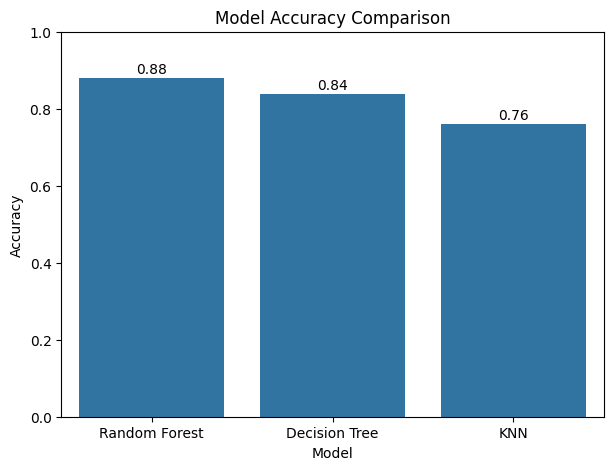

In [31]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

for i, value in enumerate(results["Accuracy"]):
    plt.text(i, value + 0.01, f"{value:.2f}", ha="center")

plt.savefig("images/model_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

# 8. Model Evaluation

The best-performing model (Random Forest) is evaluated using:

- Classification Report
- Confusion Matrix
- Accuracy Score

In [32]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

  Downstairs       0.69      0.48      0.56       101
     Jogging       0.95      0.99      0.97       323
     Sitting       1.00      1.00      1.00        27
    Standing       1.00      1.00      1.00        15
    Upstairs       0.76      0.56      0.64       117
     Walking       0.87      0.98      0.92       406

    accuracy                           0.88       989
   macro avg       0.88      0.83      0.85       989
weighted avg       0.87      0.88      0.87       989



### Interpretation

The Random Forest classifier achieved the highest overall accuracy of **88.07%**.

The model classified **Jogging**, **Walking**, **Sitting**, and **Standing** with high precision and recall. Lower performance for **Upstairs** and **Downstairs** is expected because these activities have similar movement patterns, making them more difficult to distinguish.

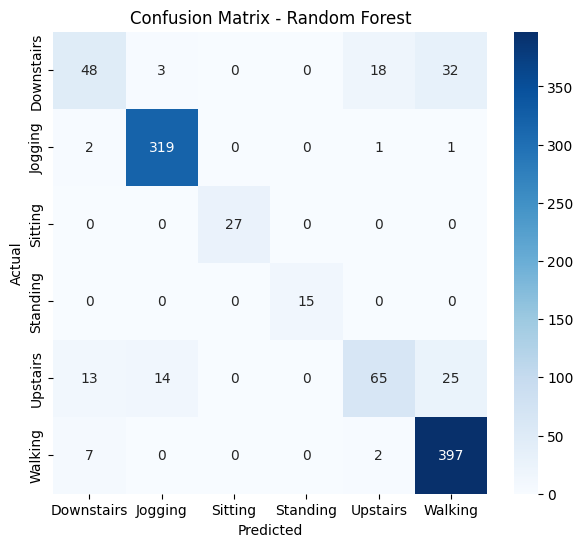

In [33]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.savefig("images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# 9. Feature Importance

Random Forest provides feature importance scores that indicate which sensor-derived features contributed the most to activity classification.

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
40,YSTANDDEV,0.137431
37,YABSOLDEV,0.125968
38,ZABSOLDEV,0.096384
42,RESULTANT,0.089948
32,ZAVG,0.070751
31,YAVG,0.060720
39,XSTANDDEV,0.044034
41,ZSTANDDEV,0.041999
34,YPEAK,0.039743
36,XABSOLDEV,0.036190


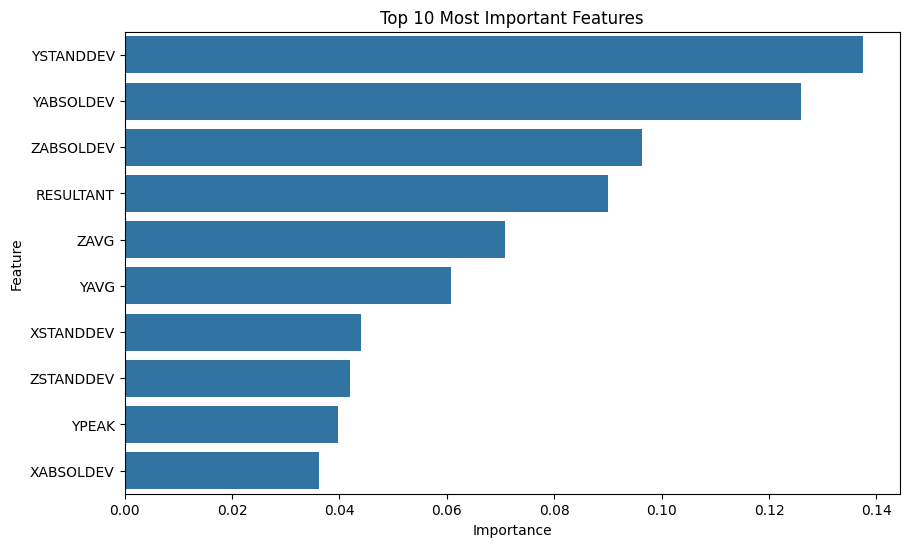

In [35]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")

plt.savefig("images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# 10. Sample Prediction

The trained Random Forest model is tested on a sample from the test dataset to compare the predicted activity with the actual activity.

In [36]:
sample = X_test.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Activity:", encoder.inverse_transform(prediction)[0])
print("Actual Activity   :", encoder.inverse_transform([y_test[0]])[0])

Predicted Activity: Jogging
Actual Activity   : Jogging


In [37]:
# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained model
joblib.dump(rf_model, "models/random_forest.pkl")

# Save the scaler
joblib.dump(scaler, "models/scaler.pkl")

# Save the label encoder
joblib.dump(encoder, "models/label_encoder.pkl")

print("Model saved successfully!")

Model saved successfully!


# Conclusion

In this project, a Human Activity Recognition (HAR) system was developed using the official WISDM Activity Recognition dataset. After preprocessing the data, three machine learning models—Decision Tree, K-Nearest Neighbors (KNN), and Random Forest—were trained and evaluated.

Among the evaluated models, the Random Forest classifier achieved the highest accuracy of **88.07%**, outperforming the other algorithms. The model successfully recognized six human activities and demonstrated excellent performance for activities such as Jogging, Walking, Sitting, and Standing.

Overall, the project demonstrates that machine learning algorithms can effectively classify human activities using smartphone sensor-derived features. Such systems have practical applications in healthcare monitoring, fitness tracking, wearable devices, and smart environments.